In [ ]:
import requests
import csv
import pandas as pd
import plotly.express as px
from textblob import TextBlob
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim import corpora, models
from gensim.models import Word2Vec
import nltk
import re
from nltk.corpus import stopwords

# download nltk data
nltk.download('punkt')
nltk.download('stopwords')

# Canvas API relative info
access_token = ""  # your token
course_id = "147283"  # course ID

# Canvas API URL
discussion_url = f"https://canvas.ubc.ca/api/v1/courses/{course_id}/discussion_topics"

# The request header contains the access token
headers = {
    "Authorization": f"Bearer {access_token}"
}

# Send a GET request to get discussion topic data
response = requests.get(discussion_url, headers=headers)

# Create an empty list to store discussion topics and their replies
discussion_data = []
student_participation = defaultdict(lambda: {'discussions': 0, 'replies': 0, 'quality_score': 0, 'sentiment_score': 0, 'lexical_richness': 0, 'topics': []})

# 定义函数计算词汇丰富度 (Type-Token Ratio)
def calculate_lexical_richness(content):
    words = content.split()
    unique_words = set(words)
    if len(words) == 0:
        return 0
    return len(unique_words) / len(words)

# 定义函数计算回复质量（根据字数来打分）
def calculate_quality(content):
    word_count = len(content.split())
    if word_count > 100:
        return 5  # 高质量回复
    elif word_count > 50:
        return 3  # 中等质量回复
    else:
        return 1  # 低质量回复

# 定义函数计算情感分数
def calculate_sentiment(content):
    analysis = TextBlob(content)
    sentiment = analysis.sentiment.polarity  # 情感极性
    return sentiment

# 定义主题提取函数，使用 LDA
def extract_topics(contents, num_topics=3):
    # 生成词典和语料库
    dictionary = corpora.Dictionary([content.split() for content in contents])
    corpus = [dictionary.doc2bow(text.split()) for text in contents]

    # 训练 LDA 模型
    lda_model = models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=10)

    topics = []
    for idx, topic in lda_model.print_topics(num_topics):
        topics.append(topic)
    return topics

# 定义文本清理函数，移除 HTML 标签、特殊字符、停用词等
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 移除 HTML 标签
    text = re.sub(r'<.*?>', '', text)
    # 移除特殊字符和数字
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 转为小写
    text = text.lower()
    # 分词，过滤停用词和长度小于2的词
    filtered_words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    return ' '.join(filtered_words)

# 获取回复并进行分析
all_replies_content = []

# 检查是否成功响应
if response.status_code == 200:
    discussions = response.json()

    # 遍历讨论话题
    for discussion in discussions:
        title = discussion['title']
        author_name = discussion.get('author', {}).get('display_name', 'Unknown Author')
        posted_at = discussion.get('posted_at', 'Unknown Time')
        content = discussion.get('message', '无内容')

        # 更新发起讨论的学生统计
        student_participation[author_name]['discussions'] += 1

        # 获取每个讨论的回复数据
        discussion_id = discussion['id']
        replies_url = f"https://canvas.ubc.ca/api/v1/courses/{course_id}/discussion_topics/{discussion_id}/entries"
        replies_response = requests.get(replies_url, headers=headers)

        reply_count = 0
        if replies_response.status_code == 200:
            replies = replies_response.json()

            # 统计每个讨论的回复数量
            reply_count = len(replies)

            # 遍历每个回复
            for reply in replies:
                reply_author = reply.get('user_name', 'Unknown Reply Author')
                reply_content = reply.get('message', '无内容')

                # 更新回复次数
                student_participation[reply_author]['replies'] += 1

                # 计算回复质量评分
                quality_score = calculate_quality(reply_content)
                student_participation[reply_author]['quality_score'] += quality_score

                # 计算回复情感分数
                sentiment_score = calculate_sentiment(reply_content)
                student_participation[reply_author]['sentiment_score'] += sentiment_score

                # 计算词汇丰富度
                lexical_richness = calculate_lexical_richness(reply_content)
                student_participation[reply_author]['lexical_richness'] += lexical_richness

                # 保存回复内容以进行主题提取和关键词分析
                cleaned_reply_content = clean_text(reply_content)
                all_replies_content.append(cleaned_reply_content)

        # 将讨论数据存入列表
        discussion_data.append({
            "Discussion Title": title,
            "Author Name": author_name,
            "Posted At": posted_at,
            "Reply Count": reply_count
        })

    # 提取主题
    topics = extract_topics(all_replies_content)
    for student, data in student_participation.items():
        student_participation[student]['topics'] = topics

    # 将讨论数据写入 CSV 文件
    with open('discussion_topics.csv', mode='w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=["Discussion Title", "Author Name", "Posted At", "Reply Count"])
        writer.writeheader()
        writer.writerows(discussion_data)

    print("discussion topic and replies are successfully input into discussion_topics.csv file")
else:
    print(f"请求失败，状态码: {response.status_code}")

# 将学生参与情况写入 CSV 文件
student_data = [{'Student Name': student, 'Discussions Initiated': data['discussions'],
                 'Replies Made': data['replies'], 'Quality Score': data['quality_score'],
                 'Sentiment Score': data['sentiment_score'], 'Lexical Richness': data['lexical_richness'],
                 'Topics': ', '.join(data['topics'])}
                for student, data in student_participation.items()]

df_students = pd.DataFrame(student_data)

# 找到回复数量最多的前10个学生
df_top_students = df_students.nlargest(10, 'Replies Made')

# 进行关键词分析（TF-IDF）
vectorizer = TfidfVectorizer(max_features=10)
X = vectorizer.fit_transform(all_replies_content)
keywords = vectorizer.get_feature_names_out()
print("key word analysis：", keywords)

# 训练 Word2Vec 模型并分析词汇相似性
tokenized_replies = [nltk.word_tokenize(reply) for reply in all_replies_content]
word2vec_model = Word2Vec(sentences=tokenized_replies, vector_size=100, window=5, min_count=1, workers=4)

# 打印词汇表中的前20个单词
vocab = list(word2vec_model.wv.index_to_key)
print("Word2Vec top 20 words:", vocab[:20])

# 示例词汇相似性分析
word_to_check = 'team'
if word_to_check in word2vec_model.wv.key_to_index:
    word_similarities = word2vec_model.wv.most_similar(word_to_check, topn=5)
    print(f"Most similar words to '{word_to_check}':", word_similarities)
else:
    print(f"Word '{word_to_check}' not in the vocabulary.")

# 可视化学生的参与度、质量评分、词汇丰富度和情感评分
fig = px.bar(df_students, x='Student Name', y=['Discussions Initiated', 'Replies Made', 'Quality Score', 'Sentiment Score', 'Lexical Richness'],
             title="Students participate in discussions on quality rating, emotional rating, and vocabulary enrichment",
             labels={'value': '数量 / 评分', 'variable': '评分标准'}, barmode='group')

fig.show()


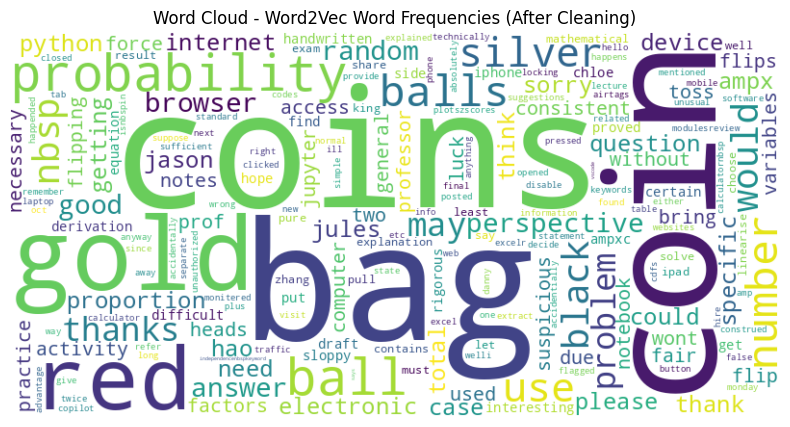

In [40]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 生成基于清理后文本的全局词云
# 获取词汇表中每个词的频率
word_freq = {word: word2vec_model.wv.get_vecattr(word, "count") for word in word2vec_model.wv.index_to_key}

# 创建词云图使用词频
wordcloud_freq = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

# 显示词云图
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_freq, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Word2Vec Word Frequencies (After Cleaning)")
plt.show()
